In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
#CSV with Corrupted Images
#For Windows
#nbs = pd.read_csv('E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\NewBiasDataset\\newsmediabias_plus_combined.csv')
#for Mac
nbs = pd.read_csv('/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/newsmediabias_plus_combined.csv')





In [ ]:
nbs.head()

In [ ]:
nbs.columns

In [ ]:
nbs.dtypes

In [ ]:
nbs['multimodal_label_x'].unique()

In [ ]:
nbs['text_label_x'].unique()

In [ ]:
nbs['text_label_y'].unique()

In [ ]:
nbs.head()

In [ ]:
count = nbs['image_description_x'] == nbs['image_description_y']
count.value_counts()

Removing the columns containing url and date

In [ ]:
col = ['date_published_x','article_url','canonical_link_x','source_url_x','date_published_y','canonical_link_y','source_url_y']
nbs = nbs.drop(columns=col,axis=1)

In [ ]:
nbs.columns


In [ ]:


nbs['mac_image_path'] = '/Users/ritikrmohapatra/Downloads/images/' + nbs['image_filename'].astype(str)



In [ ]:
nbs[nbs['image_filename']=='28a35599e8.jpg'].value_counts()


In [ ]:
from PIL import Image

path = nbs.loc[nbs['image_filename']=='28a35599e8.jpg', 'mac_image_path'].values[0]

img = Image.open(path)
img.show()


In [ ]:
nbs['mac_image_path']

In [ ]:

import os
from PIL import Image

def remove_corrupted_image(path,dataset):
    path=path.replace('\\','/')
    try:
        img=Image.open(path)
        img.verify() 
        return False 
    except (IOError, SyntaxError) as e:
        print(f"Removing corrupted image: {path} - {e}")
        dataset.drop(dataset[dataset['mac_image_path'] == path].index,inplace=True)
        return True 


In [ ]:
nbs['mac_image_path'].apply(lambda x : remove_corrupted_image(x,nbs))

In [ ]:
nbs = nbs.reset_index(drop=True)


In [ ]:
nbs.shape[0]

In [ ]:
nbs.shape[0]

In [ ]:
nbs.to_csv('No_Corrupted_NBS.csv',index=False)

In [ ]:
# For windows
# nbs = pd.read_csv('E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\No_Corrupted_NBS.csv')
#For Mac
nbs = pd.read_csv('/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/No_Corrupted_NBS.csv')

In [ ]:
nbs.shape[0]

In [ ]:
nbs

In [ ]:
nbs['multimodal_label_y']


In [ ]:
nbs['mac_image_path']

In [ ]:
nbs['mac_image_path'].apply(lambda x : remove_corrupted_image(x,nbs))


In [ ]:
nbs.shape[0]

In [ ]:
from PIL import Image

img = Image.open(nbs['mac_image_path'].iloc[1])

img.show()

In [ ]:
nbs[nbs['multimodal_label_x']!=nbs['multimodal_label_y']].value_counts().sum()

In [ ]:
nbs['MultiModal_Label'] =nbs['multimodal_label_x']


In [ ]:
nbs=nbs.drop(columns=['multimodal_label_x','multimodal_label_y'])

In [ ]:
nbs.columns

In [ ]:
#Renaming the columns 

In [ ]:
nbs['caption']=nbs['image_description_x']

In [ ]:
nbs=nbs.drop(columns=['image_description_x','image_description_y'])

In [ ]:
nbs.columns

In [ ]:
nbs['text_label_x']

In [ ]:
nbs['text_label_y']

In [ ]:
nbs['text_labels']=nbs['text_label_x'].apply(lambda x : 'biased' if x=='Likely' else 'non-biased')

In [ ]:
nbs['MultiModal_Label']=nbs['MultiModal_Label'].apply(lambda x : 'biased' if x=='Likely' else 'non-biased')

In [ ]:
nbs['text_labels']

In [ ]:
nbs=nbs.drop(columns=['text_label_x','text_label_y'])

In [ ]:
nbs['Outlet'] = nbs['outlet_x']
nbs=nbs.drop(columns=['outlet_x','outlet_y'])

In [ ]:
nbs.columns

In [ ]:
nbs['new_categories'].unique()

In [ ]:
plt.hist(nbs['text_labels'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

In [ ]:
plt.hist(nbs['MultiModal_Label'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

In [ ]:
nbs.head()

In [ ]:
nbs['Outlet'].unique()

In [ ]:
count_biasedandnonbiased_wrt_outlets=nbs.groupby(nbs['MultiModal_Label'])['Outlet'].value_counts()

In [ ]:
count_biasedandnonbiased_wrt_outlets

In [ ]:
nbs['Label_Match_Table']=nbs['MultiModal_Label']==nbs['text_labels']


In [ ]:
nbs.groupby(['Label_Match_Table'])['Label_Match_Table'].value_counts()

In [ ]:
#Here we can see that the labels for text and image+text is different in more than half of the data

In [ ]:
#It would be really better if we input the model for both the text and multimodal labels are we can see that the images are also biased so there is a difference in the bias labels for the multimodal prediction

In [ ]:
nbs.head()

In [ ]:
len(nbs['Outlet'].unique())


In [ ]:
nbs['Outlet'].value_counts()

In [ ]:
dataset_for_plotting_text_labels = nbs[['text_labels','Outlet']]
dataset_for_plotting_MultiModal_Label = nbs[['MultiModal_Label','Outlet']]

In [ ]:
dataset_for_plotting_MultiModal_Label.head()


In [ ]:
dataset_for_plotting_MultiModal_Label.shape[0]

In [ ]:
dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet'] == 'CBC.ca']

In [ ]:
for i in dataset_for_plotting_MultiModal_Label['Outlet'].unique():
    dataset_for_plotting_MultiModal_Label = dataset_for_plotting_MultiModal_Label.groupby('Outlet').filter(lambda x: len(x) >= 100)


In [ ]:
for i in dataset_for_plotting_text_labels['Outlet'].unique():
    dataset_for_plotting_text_labels = dataset_for_plotting_text_labels.groupby('Outlet').filter(lambda x: len(x) >= 100)


In [ ]:
dataset_for_plotting_MultiModal_Label.shape[0]

In [ ]:
len(dataset_for_plotting_MultiModal_Label['Outlet'].unique())

In [ ]:

dataset_for_plotting_text_labels

In [ ]:

topic=dataset_for_plotting_MultiModal_Label['Outlet'].unique()
x= np.arange(len(topic))


width=0.4
for i in x:
    plt.bar(i-0.4, (dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet']==topic[i]]['MultiModal_Label'] == 'biased').sum(), width, color='cyan')
    plt.bar(i, (dataset_for_plotting_MultiModal_Label[dataset_for_plotting_MultiModal_Label['Outlet']==topic[i]]['MultiModal_Label'] == 'non-biased').sum(), width, color='green')
plt.xticks(x,topic,rotation='vertical')
plt.legend(nbs['MultiModal_Label'].unique())
plt.xlabel('Outlet Name')
plt.ylabel('Frequency')
plt.title('Multimodal Label distribution in respect to different outlets')
plt.grid(True)
plt.plot()

In [ ]:
topic=dataset_for_plotting_text_labels['Outlet'].unique()
x= np.arange(len(topic))

width=0.4
for i in x:
    plt.bar(i-0.4, (dataset_for_plotting_text_labels[dataset_for_plotting_text_labels['Outlet']==topic[i]]['text_labels'] == 'biased').sum(), width, color='cyan')
    plt.bar(i, (dataset_for_plotting_text_labels[dataset_for_plotting_text_labels['Outlet']==topic[i]]['text_labels'] == 'non-biased').sum(), width, color='green')
plt.xticks(x,topic,rotation='vertical')
plt.legend(nbs['text_labels'].unique())
plt.xlabel('Outlet Name')
plt.ylabel('Frequency')
plt.title('text_labels distribution in respect to different outlets')
plt.grid(True)
plt.plot()

nbs.columns

Removing non words 

In [ ]:
nbs['article_text'] = nbs['article_text'].replace(to_replace=r'[^\w\s]', value='', regex=True)
nbs['caption'] = nbs['caption'].replace(to_replace=r'[^\w\s]', value='', regex=True)


Lower casing the text

In [ ]:
nbs = nbs.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [ ]:
nbs.head()

In [ ]:
nbs.describe()

In [ ]:
nbs.isna().sum()

In [ ]:
nbs.shape[0]

In [ ]:
nbs.head()

In [ ]:
nbs['image_path'][1].replace('\\','/')

In [ ]:
#This dataset shows that the multimodal bias distribution has a leaning towards being biased a little biased.And we can also see that text labels and multimodal labels differ a bit and it can also be infered that the images affect the bias classification of the article .
#

In [ ]:
nbs.columns

In [ ]:
nbs['new_categories']

In [ ]:
nbs.head()

In [ ]:
nbs.isna().sum()

In [ ]:
nbs['MultiModal_Label'] = nbs['MultiModal_Label'].apply(lambda x: 1 if x == 'biased' else 0)

In [ ]:
nbs['MultiModal_Label'].describe()

In [ ]:
nbs.shape[0]


In [ ]:
nbs

In [490]:
nbs_=nbs.iloc[:1299]

In [491]:
nbs_=nbs_[['caption','MultiModal_Label','mac_image_path']]
nbs_.rename(columns={
    'caption': 'caption',
    'MultiModal_Label': 'MultiModal_Label',
    'mac_image_path': 'image_path' 
},inplace=True)


'''Change the quntity of data'''

In [492]:
nbs_

,caption,MultiModal_Label,image_path
0,two individuals with backpacks walking on a ci...,0,/users/ritikrmohapatra/downloads/images/0bad32...
1,a character with blue hair and a green dress s...,0,/users/ritikrmohapatra/downloads/images/004798...
2,the image shows a closeup of a police badge wi...,0,/users/ritikrmohapatra/downloads/images/256b48...
3,a woman with blonde hair wearing a white shirt...,0,/users/ritikrmohapatra/downloads/images/0ca60e...
4,the image shows the seal of the cia featuring ...,0,/users/ritikrmohapatra/downloads/images/06cc5b...
...,...,...,...
1294,the image shows the iconic eiffel tower with t...,1,/users/ritikrmohapatra/downloads/images/014241...
1295,a man in a blue and gold costume stands confid...,0,/users/ritikrmohapatra/downloads/images/1c7da5...
1296,a flooded street with fallen trees and a damag...,1,/users/ritikrmohapatra/downloads/images/003354...
1297,a man stands at a podium with a microphone sur...,0,/users/ritikrmohapatra/downloads/images/0809ad...


[]

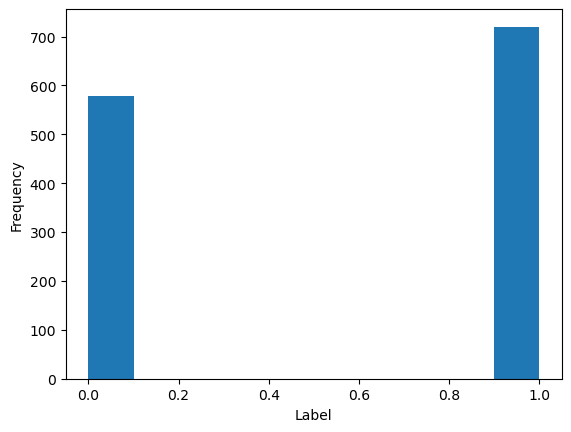

In [493]:
plt.hist(nbs_['MultiModal_Label'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.plot()

In [494]:
#nbs_text_and_image = nbs.drop(columns=['unique_id'])

Train Test Split

In [564]:

X_train, X_test = train_test_split(nbs_, test_size=0.2, random_state=42, stratify=nbs_['MultiModal_Label'])


In [565]:
X_train['MultiModal_Label'].value_counts()

MultiModal_Label
1    576
0    463
Name: count, dtype: int64

Function for Data Processing

In [566]:
X_test['MultiModal_Label'].value_counts()

MultiModal_Label
1    144
0    116
Name: count, dtype: int64

In [567]:
#def Data_Processing(Dataset,Multilabel_column):
    

Importing the pretrained multimodal model from huggin face that is trained on NBS+ Dataset

Ref : https://huggingface.co/maximuspowers/multimodal-bias-classifier

In [607]:
import torch
from torch import nn
from transformers import BertModel,AutoModel
from huggingface_hub import hf_hub_download
from typing import Literal
import json

class MultimodalClassifier(nn.Module):
    def __init__(
            self,
            text_encoder_id_or_path: str,
            image_encoder_id_or_path: str,
            projection_dim: int,
            fusion_method: Literal["concat", "align", "cosine_similarity"] = "concat",
            proj_dropout: float = 0.1,
            fusion_dropout: float = 0.1,
            num_classes: int = 1,
            
        ) -> None:
        super().__init__()

        self.fusion_method = fusion_method
        self.projection_dim = projection_dim
        self.num_classes = num_classes

        ##### Text Encoder
        self.text_encoder = BertModel.from_pretrained(text_encoder_id_or_path)
        self.text_projection = nn.Sequential(
            nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Image Encoder (using ResNet34 from AutoModel with timm)
        self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
        self.image_encoder.classifier = nn.Identity()  # rm the classification head
        self.image_projection = nn.Sequential(
            nn.Linear(512, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Fusion Layer
        fusion_input_dim = self.projection_dim * 2 if fusion_method == "concat" else self.projection_dim
        self.fusion_layer = nn.Sequential(
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_input_dim, self.projection_dim),
            nn.GELU(),
            nn.Dropout(fusion_dropout),
        )

        ##### Classification Layer
        self.classifier = nn.Linear(self.projection_dim, self.num_classes)

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        ##### Text Encoder Projection #####
        full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
        full_text_features = full_text_features[:, 0, :]  # using cls token
        full_text_features = self.text_projection(full_text_features)

        ##### Image Encoder Projection #####
        resnet_image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state
        
        # global average pooling for resent image features (bad idea? dim problems)
        resnet_image_features = resnet_image_features.mean(dim=[-2, -1])
        resnet_image_features = self.image_projection(resnet_image_features)

        ##### Fusion and Classification #####
        if self.fusion_method == "concat":
            fused_features = torch.cat([full_text_features, resnet_image_features], dim=-1)
        else:
            fused_features = full_text_features * resnet_image_features # don't think this works atm (should be dot prod)

        # fusion and classifier layers
        fused_features = self.fusion_layer(fused_features)
        classification_output = self.classifier(fused_features)

        return classification_output

def load_model():
    
    config = {
        "model_type": "multimodal-bias-classifier", 
        #"text_encoder_id_or_path": "E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\Model_config", #For Windows
        "text_encoder_id_or_path": "/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config",
        "image_encoder_id_or_path": "resnet34", 
        "projection_dim": 768, 
        "fusion_method": "concat", 
        "num_classes": 1, "proj_dropout": 0.1, 
        "fusion_dropout": 0.1, "hidden_size": 768, 
        "save_components": ["resnet_encoder", "text_encoder", "fusion_layer", "classifier"], 
        "exclude_components": ["clip_text_encoder", "clip_image_encoder"]}
    model = MultimodalClassifier(
        text_encoder_id_or_path=config["text_encoder_id_or_path"],
        image_encoder_id_or_path="microsoft/resnet-34",
        projection_dim=config["projection_dim"],
        fusion_method=config["fusion_method"],
        proj_dropout=config["proj_dropout"],
        fusion_dropout=config["fusion_dropout"],
        num_classes=config["num_classes"]
    )

    model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
    checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu')) #wINDOWS 

    model.load_state_dict(checkpoint, strict=False)

    return model


Declaring Tokenizer

In [569]:
import torch
from transformers import AutoTokenizer
from PIL import Image
import requests
from torchvision import transforms

model = load_model()
model.eval()





Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

NameError: name 'pixel_values' is not defined

In [570]:
print(model)

MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [571]:
!pip install torchinfo

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [572]:
import torchinfo

torchinfo.summary(model, col_names = ["num_params", "params_percent", "trainable"], depth = 4, row_settings = ["var_names"], verbose = 1);


Layer (type (var_name))                                                     Param #                   Param %                   Trainable
MultimodalClassifier (MultimodalClassifier)                                 --                             --                   True
├─BertModel (text_encoder)                                                  --                             --                   True
│    └─BertEmbeddings (embeddings)                                          --                             --                   True
│    │    └─Embedding (word_embeddings)                                     23,440,896                 25.93%                   True
│    │    └─Embedding (position_embeddings)                                 393,216                     0.43%                   True
│    │    └─Embedding (token_type_embeddings)                               1,536                       0.00%                   True
│    │    └─LayerNorm (LayerNorm)                               

In [573]:
model.classifier

Linear(in_features=768, out_features=1, bias=True)

In [574]:
device = torch.device(device = "cuda" if torch.cuda.is_available() else "cpu") #Windows GPU


model.to(device)

MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

Dataloader

In [575]:
text_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [576]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class DATA(Dataset):
    def __init__(self, dataframe, text_tokenizer, image_transform):
        self.df = dataframe
        self.text_tokenizer = text_tokenizer
        self.image_transform = image_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row['caption']
        image_path = row['image_path']

        # tokenize text
        text_inputs = self.text_tokenizer(
            text, padding='max_length', truncation=True, max_length=512 , return_tensors='pt'
        )
        # transform image
        image = Image.open(image_path).convert('RGB')
        image_input = self.image_transform(image)

        #label = torch.tensor(row['MultiModal_Label'])
        
        input_ids= text_inputs['input_ids'][0]
        attention_mask= text_inputs['attention_mask']
        pixel_values = image_input
        labels =  int(row['MultiModal_Label'])
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'pixel_values': image_input,
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Then create dataset and loader

train_loader_dataset = DATA(X_train, text_tokenizer, image_transform)
test_loader_dataset = DATA(X_test, text_tokenizer, image_transform)

training_loader = DataLoader(train_loader_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(test_loader_dataset, batch_size=8, shuffle=True)

In [577]:
train_loader_dataset

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [578]:
import torch
torch.cuda.empty_cache()

In [579]:
from tqdm import tqdm

loss_function = torch.nn.BCEWithLogitsLoss()
LEARNING_RATE=2e-5




def calcuate_accuracy(preds, targets):
    n_correct = (preds==targets).sum().item()
    return n_correct

def calculate_truth_value(preds,targets):
    n_True_pos = ((preds==targets)&(targets==1)).sum().item()
    n_False_pos = ((preds!=targets)&(targets==0)).sum().item()
    n_True_neg = ((preds==targets)&(targets==0)).sum().item()
    n_False_neg = ((preds!=targets)&(targets==1)).sum().item()
    return n_True_pos,n_False_pos,n_True_neg,n_False_neg

def train(epoch, training_loader,LEARNING_RATE=2e-5,threshold=0.5):

    optimizer = torch.optim.Adam(params =  model.parameters(), lr=LEARNING_RATE)

    tr_loss = 0
    n_correct = 0
    nb_tr_steps = 0
    nb_tr_examples = 0
    True_pos= 0 
    False_pos=0
    True_neg=0
    False_neg=0
    n_True_pos=0;n_False_pos=0;n_True_neg=0;n_False_neg=0
    model.train()
    for _,data in tqdm(enumerate(training_loader, 0)):
        ids = data['input_ids'].to(device, dtype = torch.long)
        mask = data['attention_mask'].to(device, dtype = torch.long)
        pixel_values = data['pixel_values'].to(device, dtype = torch.float)
        targets = data['labels'][:, None].to(device, dtype = torch.float)

        outputs = model(input_ids=ids,
            attention_mask=mask,
            pixel_values=pixel_values)
        loss = loss_function(outputs, targets)
        tr_loss += loss.item()
        preds = torch.sigmoid(outputs) > threshold        
        n_correct += calcuate_accuracy(preds, targets.bool())

        n_True_pos,n_False_pos,n_True_neg,n_False_neg = calculate_truth_value(preds, targets.bool())
        True_pos += n_True_pos
        False_pos += n_False_pos
        True_neg += n_True_neg
        False_neg += n_False_neg

        nb_tr_steps += 1
        nb_tr_examples+=targets.size(0)
        
        if _%500==0:
            loss_step = tr_loss/nb_tr_steps
            accu_step = (n_correct*100)/nb_tr_examples 

        optimizer.zero_grad()
        loss.backward()
        # # When using GPU
        optimizer.step()

    
    epoch_loss = tr_loss/nb_tr_steps
    epoch_accu = (n_correct*100)/nb_tr_examples
    print(f'The Total Accuracy for TRaining Epoch {epoch}:{epoch_accu}')

    return model,epoch_accu,epoch_loss
 



def valid(model, testing_loader,threshold=0.5):
    model.eval()
    n_correct = 0; n_wrong = 0; total = 0; tr_loss=0; nb_tr_steps=0; nb_tr_examples=0 ; True_pos=0; False_pos=0; True_neg=0; False_neg=0; n_True_pos=0;n_False_pos=0;n_True_neg=0;n_False_neg=0
    all_preds=[]
    all_targets=[]
    with torch.no_grad():
        for _, data in tqdm(enumerate(testing_loader, 0)):
            ids = data['input_ids'].to(device, dtype = torch.long)
            mask = data['attention_mask'].to(device, dtype = torch.long)
            pixel_values = data['pixel_values'].to(device, dtype = torch.float)
            targets = data['labels'].reshape(-1,1).to(device, dtype = torch.float)

            all_targets.append(targets.bool())

            outputs = model(input_ids=ids,
            attention_mask=mask,
            pixel_values=pixel_values)

            loss = loss_function(outputs, targets)
            tr_loss += loss.item()
            preds = torch.sigmoid(outputs) > threshold
            all_preds.append(preds)

            n_correct += calcuate_accuracy(preds, targets.bool())

            n_True_pos,n_False_pos,n_True_neg,n_False_neg = calculate_truth_value(preds, targets)
            True_pos += n_True_pos
            False_pos += n_False_pos
            True_neg += n_True_neg
            False_neg += n_False_neg


            nb_tr_steps += 1
            nb_tr_examples+=targets.size(0)
            
            if _%5000==0:
                loss_step = tr_loss/nb_tr_steps
                accu_step = (n_correct*100)/nb_tr_examples

    

    epoch_loss = tr_loss/nb_tr_steps
    epoch_accu = (n_correct*100)/nb_tr_examples
    
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_targets = torch.cat(all_targets).cpu().numpy()

    return epoch_accu,True_pos,False_pos,True_neg,False_neg,epoch_loss,all_preds,all_targets

#https://stackoverflow.com/questions/62301674/extracting-labels-after-applying-softmax  --> For Probability, Weights and Labels

In [580]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(all_targets,all_pred):
    cm = confusion_matrix(all_targets, all_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    plt.figure(figsize=(6,6))
    disp.plot(cmap=plt.cm.Blues, values_format='d')  
    plt.title("Confusion Matrix")
    plt.show()

In [581]:
def eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg):                                      
    recall_deno = n_True_pos+n_False_neg                               
    recall = n_True_pos/recall_deno
    print(recall)

    Precision_dino = n_True_pos + n_False_pos                                                                                                                                                  
    Precision = n_True_pos/Precision_dino             
    print(Precision)                                                                                            
    F1_dino = Precision+recall
    F1_num= 2*Precision*recall
    F1= F1_num/F1_dino
    print(F1)

    return F1

130it [16:33,  7.64s/it]


The Total Accuracy for TRaining Epoch 0:54.66794995187681
Epoch 0:
Training Accuracy : 54.66794995187681
Training Loss : 0.7732796382445556


33it [00:59,  1.81s/it]

validation Accuracy : 58.07692307692308
validation Loss : 0.663029381723115
True Positives : 128
n_False_pos : 93
n_True_neg : 23
n_False_neg : 16


<Figure size 600x600 with 0 Axes>

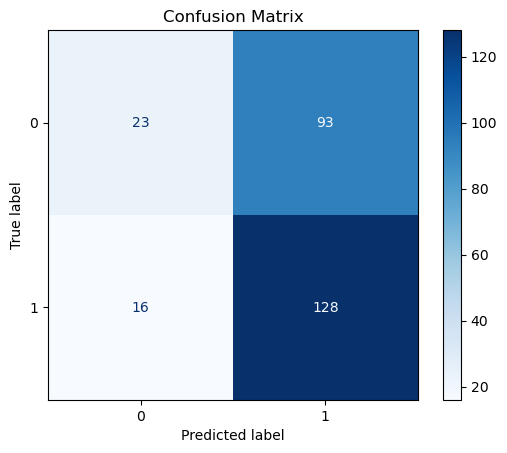

0.8888888888888888
0.579185520361991
0.7013698630136986
F1 Score: 0.7013698630136986


130it [16:00,  7.39s/it]


The Total Accuracy for TRaining Epoch 1:65.73628488931665
Epoch 1:
Training Accuracy : 65.73628488931665
Training Loss : 0.6238031754126916


33it [00:54,  1.65s/it]

validation Accuracy : 58.07692307692308
validation Loss : 0.6731026317134048
True Positives : 135
n_False_pos : 100
n_True_neg : 16
n_False_neg : 9


<Figure size 600x600 with 0 Axes>

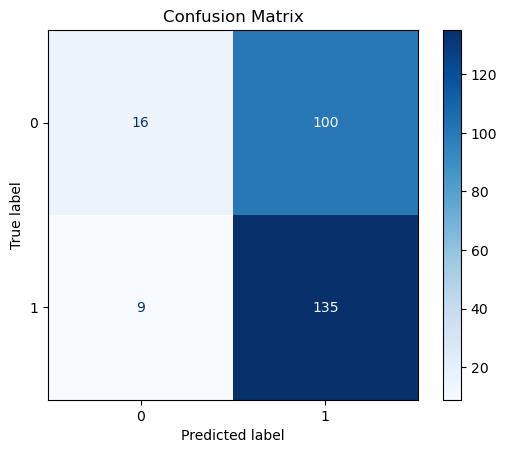

0.9375
0.574468085106383
0.7124010554089709
F1 Score: 0.7124010554089709


130it [15:10,  7.00s/it]


The Total Accuracy for TRaining Epoch 2:76.8046198267565
Epoch 2:
Training Accuracy : 76.8046198267565
Training Loss : 0.4627540214703633


33it [00:56,  1.70s/it]

validation Accuracy : 57.30769230769231
validation Loss : 0.7720967702793352
True Positives : 88
n_False_pos : 55
n_True_neg : 61
n_False_neg : 56


<Figure size 600x600 with 0 Axes>

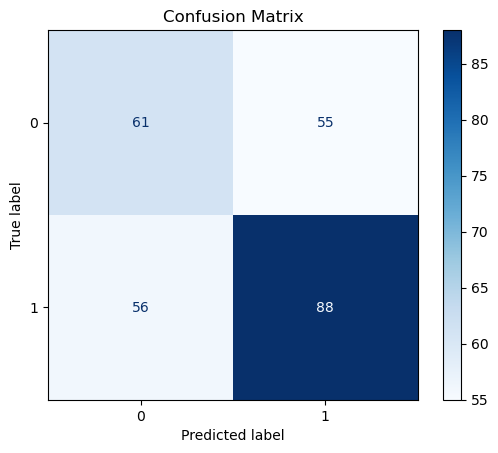

0.6111111111111112
0.6153846153846154
0.613240418118467
F1 Score: 0.613240418118467


In [582]:
'''
-------------Trained Model-----------------
'''

train_acc_history = []
train_loss_history = []

valid_acc_history = []
valid_loss_history = []

EPOCHS = 3
for epoch in range(0,EPOCHS):
    model,epoch_accu,epoch_loss=train(epoch, training_loader)
    print(f'Epoch {epoch}:')
    print(f'Training Accuracy : {epoch_accu}')
    print(f'Training Loss : {epoch_loss}')

    train_acc_history.append(epoch_accu)
    train_loss_history.append(epoch_loss)

    
    acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg,val_epoch_loss,all_preds,all_targets = valid(model, val_loader)
    print(f'validation Accuracy : {acc}')
    print(f'validation Loss : {val_epoch_loss}')

    valid_acc_history.append(acc)
    valid_loss_history.append(val_epoch_loss)

    print(f'True Positives : {n_True_pos}')
    print(f'n_False_pos : {n_False_pos}')
    print(f'n_True_neg : {n_True_neg}')
    print(f'n_False_neg : {n_False_neg}')
    plot_confusion_matrix(all_targets,all_preds)
    print(f'F1 Score: {eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)}')

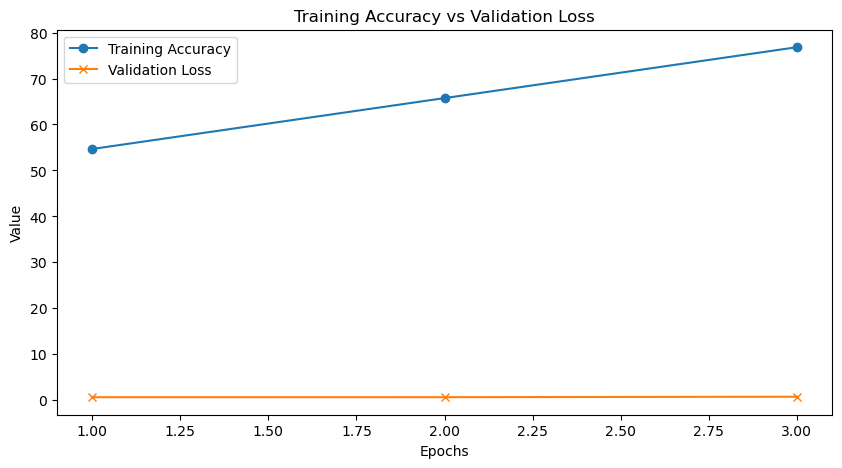

In [583]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_acc_history, label='Training Accuracy', marker='o')
plt.plot(epochs_range, valid_loss_history, label='Validation Loss', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Accuracy vs Validation Loss')
plt.legend()
plt.show()

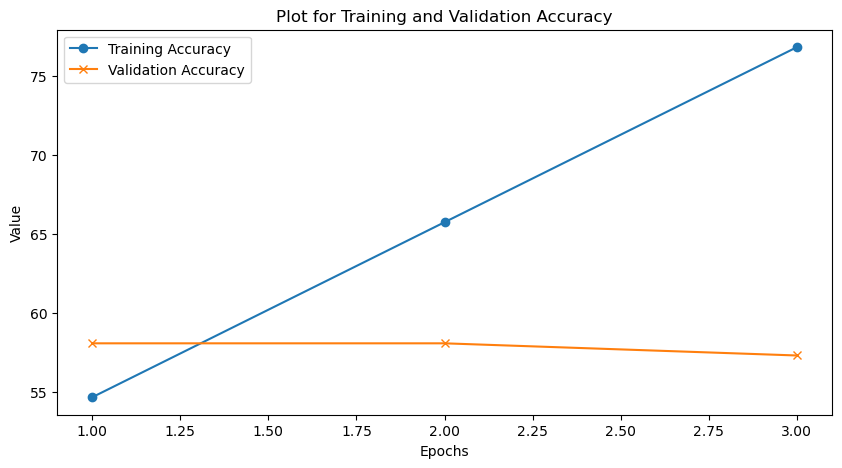

In [584]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10,5))
plt.plot(epochs_range, train_acc_history, label='Training Accuracy', marker='o')
plt.plot(epochs_range, valid_acc_history, label='Validation Accuracy', marker='x')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Plot for Training and Validation Accuracy')
plt.legend()
plt.show()

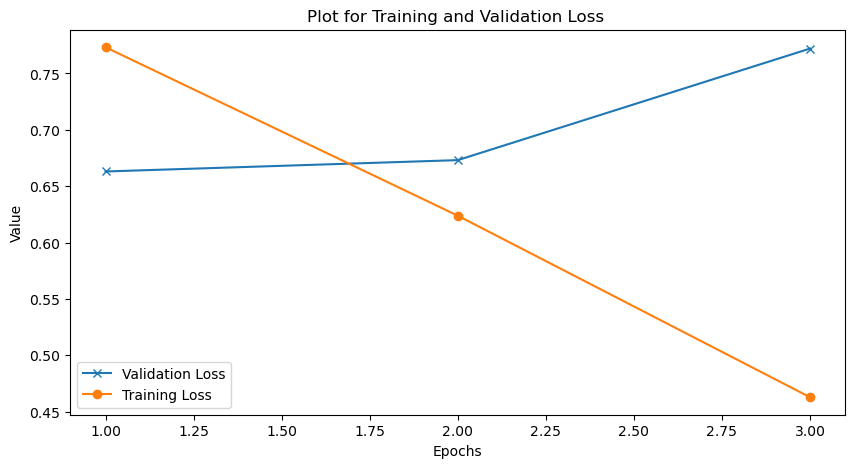

In [585]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10,5))
plt.plot(epochs_range, valid_loss_history, label='Validation Loss', marker='x')
plt.plot(epochs_range, train_loss_history, label='Training Loss', marker='o')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Plot for Training and Validation Loss ')
plt.legend()
plt.show()

In [586]:
'''
---------Model Saved after Training---------
'''
torch.save(model.state_dict(), "fine_tuned_model_nbs.pt")


In [587]:
dict=torch.load("fine_tuned_model_nbs.pt")


In [588]:
model = load_model()
model.load_state_dict(dict)
model.eval()

Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalClassifier(
  (text_encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [589]:
nbs_.shape[0]

1299

In [590]:
nbs_opt=nbs_.iloc[:500]

Optimization

In [591]:

X_train_opt, X_test_opt = train_test_split(nbs_opt, test_size=0.2, random_state=42, stratify=nbs_opt['MultiModal_Label'])


In [592]:
import sys
!{sys.executable} -m pip install hyperopt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [593]:
from hyperopt import hp,STATUS_OK

space = {
    'LEARNING_RATE': hp.uniform('LEARNING_RATE', 1e-6, 5e-5),
    'batch_size': hp.choice('batch_size', [8,16,32]),
    'epoch': hp.quniform('epoch', 1,9,1),
    'threshold' : hp.uniform('threshold', 0.0, 1.0),
    'drop' : hp.uniform('drop', 0.0, 0.8)
}

In [ ]:
def obj_func(params):
    try:

        """Parameter"""

        batch_size = params['batch_size']
        epochs = int(params['epoch'])
        LEARNING_RATE = params['LEARNING_RATE']
        threshold = params['threshold']
        drop = params['drop']
        """Model Declaration"""

        class MultimodalClassifier(nn.Module):
            def __init__(
                    self,
                    text_encoder_id_or_path: str,
                    image_encoder_id_or_path: str,
                    projection_dim: int,
                    fusion_method: Literal["concat", "align", "cosine_similarity"] = "concat",
                    proj_dropout: float = 0.1,
                    fusion_dropout: float = drop,
                    num_classes: int = 1,
                ) -> None:
                super().__init__()

                self.fusion_method = fusion_method
                self.projection_dim = projection_dim
                self.num_classes = num_classes

                ##### Text Encoder
                self.text_encoder = BertModel.from_pretrained(text_encoder_id_or_path)
                self.text_projection = nn.Sequential(
                    nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
                    nn.Dropout(proj_dropout),
                )

                ##### Image Encoder (using ResNet34 from AutoModel with timm)
                self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
                self.image_encoder.classifier = nn.Identity()  # rm the classification head
                self.image_projection = nn.Sequential(
                    nn.Linear(512, self.projection_dim),
                    nn.Dropout(proj_dropout),
                )

                ##### Fusion Layer
                fusion_input_dim = self.projection_dim * 2 if fusion_method == "concat" else self.projection_dim
                self.fusion_layer = nn.Sequential(
                    nn.Dropout(fusion_dropout),
                    nn.Linear(fusion_input_dim, self.projection_dim),
                    nn.GELU(),
                    nn.Dropout(fusion_dropout),
                )

                ##### Classification Layer
                self.classifier = nn.Linear(self.projection_dim, self.num_classes)

            def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
                ##### Text Encoder Projection #####
                full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
                full_text_features = full_text_features[:, 0, :]  # using cls token
                full_text_features = self.text_projection(full_text_features)

                ##### Image Encoder Projection #####
                resnet_image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state
                
                # global average pooling for resent image features (bad idea? dim problems)
                resnet_image_features = resnet_image_features.mean(dim=[-2, -1])
                resnet_image_features = self.image_projection(resnet_image_features)

                ##### Fusion and Classification #####
                if self.fusion_method == "concat":
                    fused_features = torch.cat([full_text_features, resnet_image_features], dim=-1)
                else:
                    fused_features = full_text_features * resnet_image_features # don't think this works atm (should be dot prod)

                # fusion and classifier layers
                fused_features = self.fusion_layer(fused_features)
                classification_output = self.classifier(fused_features)

                return classification_output

        def load_model():
                config = {
                    "model_type": "multimodal-bias-classifier", 
                    "text_encoder_id_or_path": "E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\Model_config", 
                    "image_encoder_id_or_path": "resnet34", 
                    "projection_dim": 768, 
                    "fusion_method": "concat", 
                    "num_classes": 1, "proj_dropout": 0.1, 
                    "fusion_dropout": 0.1, "hidden_size": 768, 
                    "save_components": ["resnet_encoder", "text_encoder", "fusion_layer", "classifier"], 
                    "exclude_components": ["clip_text_encoder", "clip_image_encoder"]
                    }

                model = MultimodalClassifier(
                    text_encoder_id_or_path=config["text_encoder_id_or_path"],
                    image_encoder_id_or_path="microsoft/resnet-34",
                    projection_dim=config["projection_dim"],
                    fusion_method=config["fusion_method"],
                    proj_dropout=config["proj_dropout"],
                    fusion_dropout=config["fusion_dropout"],
                    num_classes=config["num_classes"]
                )

                model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
                checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu')) #Windows
                model.load_state_dict(checkpoint, strict=False)

                return model



        

        """DataLoader"""

        train_loader_dataset_opt = DATA(X_train_opt, text_tokenizer, image_transform)
        test_loader_dataset_opt = DATA(X_test_opt, text_tokenizer, image_transform)

        training_loader_opt = DataLoader(train_loader_dataset_opt, batch_size=batch_size, shuffle=True)
        val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)

        """Model Initialization"""

        model = load_model()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #Windows
        model.to(device)

        """Training"""

        for i in range(0,epochs):
            print(f'Epoch {i}')
            model,epoch_accu,epoch_loss = train(i, training_loader_opt,LEARNING_RATE,threshold)

        """Validation"""
        acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg,val_epoch_loss,all_preds,all_targets = valid(model,val_loader_opt,threshold)

        accuracy = acc
        f1=eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)
        loss = -f1
        return {'loss': loss,
                'val_loss': val_epoch_loss,
                'status': STATUS_OK}
    except Exception as e:
        print("Exception:", e)
        return {'loss': 1.0, 'status': 'fail'}
    
    

In [595]:
!pip install lightgbm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [596]:
from hyperopt import fmin, tpe, Trials



In [597]:

trials = Trials()

best = fmin(
    fn=obj_func,
    space=space,
    algo=tpe.suggest,
    max_evals=15,
    trials=trials
)

print("Best hyperparameters:", best)

  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0                                               
  0%|          | 0/15 [00:01<?, ?trial/s, best loss=?]

0it [00:00, ?it/s]
1it [00:28, 28.84s/it]
2it [01:00, 30.36s/it]
3it [01:31, 30.83s/it]
4it [02:01, 30.27s/it]
5it [02:30, 29.99s/it]
6it [03:00, 29.95s/it]
7it [03:30, 29.92s/it]
8it [03:59, 29.78s/it]
9it [04:29, 29.66s/it]
10it [04:58, 29.52s/it]
11it [05:27, 29.28s/it]
12it [05:57, 29.54s/it]
13it [06:10, 24.64s/it]
13it [06:10, 28.51s/it]


The Total Accuracy for TRaining Epoch 5:65.75         
Epoch 1                                               
  0%|          | 0/15 [06:11<?, ?trial/s, best loss=?]

...

The Total Accuracy for TRaining Epoch 2:99.75                                         
Epoch 1                                                                               
 93%|█████████▎| 14/15 [7:44:56<32:13, 1933.79s/trial, best loss: -0.8620689655172414]

0it [00:00, ?it/s]
1it [00:28, 28.43s/it]
2it [00:56, 28.33s/it]
3it [01:25, 28.68s/it]
4it [01:54, 28.59s/it]
5it [02:22, 28.48s/it]
6it [02:52, 28.95s/it]
7it [03:22, 29.20s/it]
8it [03:50, 28.97s/it]
9it [04:19, 28.91s/it]
10it [04:49, 29.21s/it]
11it [05:17, 28.94s/it]
12it [05:46, 28.88s/it]
13it [05:59, 24.20s/it]
13it [05:59, 27.67s/it]


The Total Accuracy for TRaining Epoch 2:100.0                                         
 93%|█████████▎| 14/15 [7:50:56<32:13, 1933.79s/trial, best loss: -0.8620689655172414]

0it [00:00, ?it/s]
1it [00:07,  7.18s/it]
2it [00:14,  7.22s/it]
3it [00:22,  7.66s/it]
4it [00:23,  4.92s/it]
4it [00:23,  5.83s/it]


0.9259259259259259                                                                    
0.704225352112676                                                                     
0.7999999999999999                                                                    
100%|██████████| 15/15 [7:51:19<00:00, 1885.33s/trial, best loss: -0.8620689655172414]
Best hyperparameters: {'LEARNING_RATE': 1.307000525885407e-05, 'batch_size': 2, 'drop': 0.13434160067021886, 'epoch': 8.0, 'threshold': 0.4088532732031457}


In [598]:
batch_sizes = [8,16,32]   
batch_index = best['batch_size'] 
batch_size = batch_sizes[batch_index]  
epochs = int(best['epoch'])
LEARNING_RATE = best['LEARNING_RATE']
drop = best['drop']
threshold = best['threshold']

print(f'Parameter we got which are best for out model are : batch_size= {batch_size},epochs= {epochs},LEARNING_RATE= {LEARNING_RATE},threshold= {threshold},drop={drop}')

Parameter we got which are best for out model are : batch_size= 32,epochs= 8,LEARNING_RATE= 1.307000525885407e-05,threshold= 0.4088532732031457,drop=0.13434160067021886


In [603]:
class MultimodalClassifier(nn.Module):
    def __init__(
            self,
            text_encoder_id_or_path: str,
            image_encoder_id_or_path: str,
            projection_dim: int,
            fusion_method: Literal["concat", "align", "cosine_similarity"] = "concat",
            proj_dropout: float = 0.1,
            fusion_dropout: float = drop,
            num_classes: int = 1,
        ) -> None:
        super().__init__()

        self.fusion_method = fusion_method
        self.projection_dim = projection_dim
        self.num_classes = num_classes

        ##### Text Encoder
        self.text_encoder = BertModel.from_pretrained(text_encoder_id_or_path)
        self.text_projection = nn.Sequential(
            nn.Linear(self.text_encoder.config.hidden_size, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Image Encoder (using ResNet34 from AutoModel with timm)
        self.image_encoder = AutoModel.from_pretrained(image_encoder_id_or_path, trust_remote_code=True)
        self.image_encoder.classifier = nn.Identity()  # rm the classification head
        self.image_projection = nn.Sequential(
            nn.Linear(512, self.projection_dim),
            nn.Dropout(proj_dropout),
        )

        ##### Fusion Layer
        fusion_input_dim = self.projection_dim * 2 if fusion_method == "concat" else self.projection_dim
        self.fusion_layer = nn.Sequential(
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_input_dim, self.projection_dim),
            nn.GELU(),
            nn.Dropout(fusion_dropout),
        )

        ##### Classification Layer
        self.classifier = nn.Linear(self.projection_dim, self.num_classes)

    def forward(self, pixel_values: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        ##### Text Encoder Projection #####
        full_text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask, return_dict=True).last_hidden_state
        full_text_features = full_text_features[:, 0, :]  # using cls token
        full_text_features = self.text_projection(full_text_features)

        ##### Image Encoder Projection #####
        resnet_output = self.image_encoder(pixel_values=pixel_values)
        resnet_image_features = resnet_output.pooler_output
        
        # global average pooling for resent image features (bad idea? dim problems)
        resnet_image_features = resnet_image_features.mean(dim=[-2, -1])
        resnet_image_features = self.image_projection(resnet_image_features)

        ##### Fusion and Classification #####
        if self.fusion_method == "concat":
            fused_features = torch.cat([full_text_features, resnet_image_features], dim=-1)
        
        else:
            fused_features = full_text_features * resnet_image_features # don't think this works atm (should be dot prod)
        
        # fusion and classifier layers
        fused_features = self.fusion_layer(fused_features)
        classification_output = self.classifier(fused_features)

        return classification_output

def load_model():
    config = {
        "model_type": "multimodal-bias-classifier", 
        #"text_encoder_id_or_path": "E:\\GitHub\\Multi-Model-Bias-Detection-and-Debiasing-the-News\\EDA\\Model_config", #For Windows
        "text_encoder_id_or_path": "/Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config",
        "image_encoder_id_or_path": "resnet34", 
        "projection_dim": 768, 
        "fusion_method":"concat", 
        "num_classes": 1, "proj_dropout": 0.1, 
        "fusion_dropout": drop, "hidden_size": 768, 
        "save_components": ["resnet_encoder", "text_encoder", "fusion_layer", "classifier"], 
        "exclude_components": ["clip_text_encoder", "clip_image_encoder"]}


    model = MultimodalClassifier(
        text_encoder_id_or_path=config["text_encoder_id_or_path"],
        image_encoder_id_or_path="microsoft/resnet-34",
        projection_dim=config["projection_dim"],
        fusion_method=config["fusion_method"],
        proj_dropout=config["proj_dropout"],
        fusion_dropout=config["fusion_dropout"],
        num_classes=config["num_classes"]
    )

    model_weights_path = hf_hub_download(repo_id="maximuspowers/multimodal-bias-classifier", filename="model_weights.pth")
    checkpoint = torch.load(model_weights_path, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint, strict=False)

    return model


In [605]:
"""DataLoader"""

train_loader_dataset_opt = DATA(X_train, text_tokenizer, image_transform)
test_loader_dataset_opt = DATA(X_test, text_tokenizer, image_transform)

training_loader_opt = DataLoader(train_loader_dataset_opt, batch_size=batch_size, shuffle=True)
val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)

"""Model Initialization"""

model = load_model()
model.to(device)

for i in range(0,epochs):
            print(f'Epoch {i}')
            model,epoch_accu,epoch_loss = train(epochs, training_loader_opt,LEARNING_RATE,threshold)
            print(f'Epoch {i}:')
            print(f'Training Accuracy : {epoch_accu}')
            print(f'Training Loss : {epoch_loss}')

            train_acc_history.append(epoch_accu)
            train_loss_history.append(epoch_loss)

            
            
acc,n_True_pos,n_False_pos,n_True_neg,n_False_neg,val_epoch_loss,all_preds,all_targets = valid(model,val_loader_opt,threshold)
print(f'validation Accuracy : {acc}')
print(f'validation Loss : {val_epoch_loss}')


print(f'True Positives : {n_True_pos}')
print(f'n_False_pos : {n_False_pos}')
print(f'n_True_neg : {n_True_neg}')
print(f'n_False_neg : {n_False_neg}')

plot_confusion_matrix(all_targets,all_preds)

Some weights of BertModel were not initialized from the model checkpoint at /Users/ritikrmohapatra/Documents/GitHub/Multi-Model-Bias-Detection-and-Debiasing-the-News/EDA/Model_config and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 0


8it [05:12, 39.04s/it]


KeyboardInterrupt: 

In [ ]:
print(f'F1 Score: {eval(n_True_pos,n_False_pos,n_True_neg,n_False_neg)}')

0.6481481481481481
0.6140350877192983
0.6306306306306307
F1 Score: 0.6306306306306307


In [602]:
torch.save(model.state_dict(), "fine_tuned_model_nbs.pt")


#Ref For Below : https://www.kaggle.com/code/aisuko/training-models-with-hyperparameters : Used the part for training the batch from the dataloader

In [ ]:
 train_loader_dataset_opt = DATA(X_train_opt, text_tokenizer, image_transform)
        test_loader_dataset_opt = DATA(X_test_opt, text_tokenizer, image_transform)

        training_loader_opt = DataLoader(train_loader_dataset_opt, batch_size=batch_size, shuffle=True)
        val_loader_opt = DataLoader(test_loader_dataset_opt, batch_size=batch_size, shuffle=True)